In [114]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import os

C1 = '#f5f4b3' #'#3DB2FF' #'#FFAF45'
C2 = '#898|21' #'salmon'  #'#FB6D48'
C3 = '#1f4529'#'green'   #'#D74B76'
C4 = '#abba7c'#'#673F69' #'#673F69'
C5 = '#FFAF45'
C6 = '#bccbf1'

In [134]:
def read_csv_file(filename: str) -> dict:
    d = {}
    with open(filename, 'r') as rd:
        lines= rd.readlines()
        
    header = lines[0]
    header = header.strip().split(',')[1:]
    for line in lines[1:]:
        x = line.strip().split(',')
        if len(x) == 1:
            continue
        workload = x[0]
        for i in range(len(header)):
            if workload not in d:
                d[workload] = {}
            d[workload][header[i]] = float(x[i+1])
    return d

EXCLUDE = []
MPKI_MIN = 2.5

def get_stats_for_builds(builds: list[str], stat_name: str, reference_mpki: dict, reference_wrr: dict, mpki_min=MPKI_MIN, wrr_min=0.2) -> dict:
    out = {}
    
    for b in builds:
        d = read_csv_file(f'{b}.csv')
        out[b] = { w: stats[stat_name] for (w,stats) in d.items()\
                  if reference_mpki[w] >= mpki_min\
                  and reference_wrr[w] >= wrr_min\
                  and w not in EXCLUDE }
    return out

In [135]:
baseline_stats = read_csv_file('baseline.csv')
reference_mpki = { w: stats['MPKI'] for (w,stats) in baseline_stats.items() }
reference_wrr = { w: stats['Write-Read-Ratio'] for (w,stats) in baseline_stats.items() }
print(reference_mpki)

{'wrf': 19.285839574857878, 'perlbench': 0.062179974818963014, 'roms': 7.961147751474689, 'gcc': 17.78693262661958, 'cam4': 5.830682140764272, 'cactubssn': 6.342587323014237, 'exchange2': 8.999999775000006e-05, 'leela': 0.017686246883762916, 'nab': 0.16324994845754803, 'x264': 0.1510587472840596, 'lbm': 33.88558434901137, 'xz': 2.078558921082279, 'imagick': 0.03907874623316926, 'omnetpp': 12.003834909334985, 'pop2': 4.349021264968717, 'bwaves': 17.06011537609008, 'mcf': 15.176353399225095, 'fotonik3d': 18.158644308514152, 'xalancbmk': 1.9917050293769891, 'deepsjeng': 0.2956822159235451, 'bfscc': 19.100785080958314, 'triangle': 8.79043149901071, 'pagerankdelta': 19.404173833399465, 'bfs-bitvector': 16.902682667267907, 'components-shortcut': 37.21438706290469, 'radii': 44.827175816909595, 'bc': 25.445884895104044, 'cf': 16.12963350133125, 'mis': 19.421431329019285, 'bfs': 16.75002844676305, 'components': 40.541643765996696, 'pagerank': 36.43942722068181, 'bellmanford': 29.44301873342641,

In [136]:
def plot_relative_stat(output_file, builds: list[str], stat_name: str, y_label: str, labels: list, color_list: list, negate=False, percentage=False, plot_best_of_all=False):
    stats = get_stats_for_builds(builds, stat_name, reference_mpki=reference_mpki, reference_wrr=reference_wrr)

    n_labels = len(builds)
    if plot_best_of_all:
        n_labels += 1
    
    fig, ax = plt.subplots()
    fig.set_size_inches(12.0, 3.4)

    # Plot stats for each build:
    baseline_ipc_list = stats[builds[0]]
    width = 1.0 / n_labels
    off = 0

    gmean_list = []

    best_of_all = [-100 for _ in baseline_ipc_list]
    workload_order = list(baseline_ipc_list.keys())
    
    for (i, (b, ipc_list)) in enumerate(stats.items()):
        if i == 0:
            continue
        X = np.arange(len(ipc_list)+1)
        
        Y = [ ipc_list[w]/baseline_ipc_list[w] for w in workload_order ]
        best_of_all = [max(max(best_of_all[i], Y[i]), 1.0) for i in range(len(Y))]
        
        Y.append(sp.stats.gmean(Y))
        Y = np.array(Y)
        if percentage:
            Y = (Y-1) * 100
        if negate:
            Y = -Y
            
        gmean_list.append(Y[-1])
        ax.bar(X+off, Y, width, color=color_list[i-1], label=labels[i-1], zorder=3, edgecolor='k')
        off += width

    if plot_best_of_all:
        best_of_all.append(sp.stats.gmean(best_of_all))
        best_of_all = np.array(best_of_all)
        if percentage:
            best_of_all = (best_of_all-1) * 100
        if negate:
            best_of_all = best_of_all

        gmean_list.append(best_of_all[-1])
        ax.bar(X+off, best_of_all, width, color=C6, label='BoA', zorder=3, edgecolor='k')
    
    # Setup anything else that is remaining:
    workload_order.append('gmean')
    
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_xticks(X + (len(builds)-2)/2 * width, workload_order, rotation=30, ha='right', fontsize=12)
    ax.grid(visible=True, axis='y', zorder=0)
    
    ax.legend(fontsize=12, bbox_to_anchor=(0.5,1.25), ncol=n_labels, loc='upper center')
    plt.tight_layout()
    plt.savefig(output_file, bbox_inches='tight')

    # Print out gmeans:
    for (i,b) in enumerate(builds[1:]):
        g = gmean_list[i]
        print(f'{stat_name} GMEAN of {b}\t{g:.3f}')

    if plot_best_of_all:
        print(f'{stat_name} GMEAN of BoA\t{gmean_list[-1]:.3f}')
    print('----------------------------')

IPC GMEAN of wcache	1.600
IPC GMEAN of wcache_soft	1.658
IPC GMEAN of BoA	1.984
----------------------------


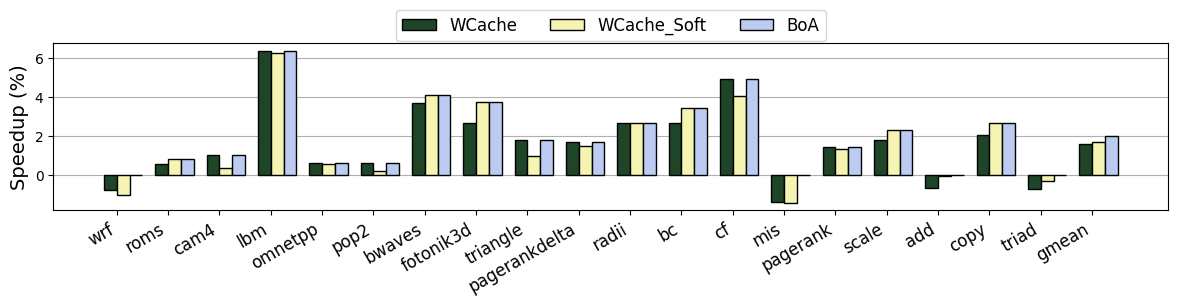

In [137]:
# Main evaluations:
plot_relative_stat('plots/main_evals_lru.pdf',
                   ['baseline', 'wcache', 'wcache_soft'],
                   'IPC',
                   'Speedup (%)',
                   ['WCache', 'WCache_Soft'],
                   [C3, C1, C4],
                   percentage=True, plot_best_of_all=True)

In [54]:
### LRU SRAM OVERHEADS

LLC_CAPACITY = 16*1024*1024 * 8
LLC_ASSOC = 16
WCACHE_SAMPLED_SETS = 64
DRAM_CHANNELS = 2
DRAM_BANKS = 32

baseline_tagdir_size = (LLC_CAPACITY/(64*8)) * (48-14-6 + 2)

wcache_counters = LLC_ASSOC*8
wcache_mark_registers = LLC_ASSOC*5*WCACHE_SAMPLED_SETS
wcache_bitvec = DRAM_CHANNELS*DRAM_BANKS
wcache_tot = baseline_tagdir_size + wcache_counters + wcache_mark_registers + wcache_bitvec

baseline_bytes = baseline_tagdir_size / 8
wcache_bytes = wcache_tot/ 8

print(wcache_bytes / baseline_bytes)
print(wcache_bytes - baseline_bytes)

1.0006754557291666
664.0


In [78]:
## SRRIP SRAM OVERHEADS
RRIP_BITS=2

wcache_counters = (2**RRIP_BITS)*8
wcache_mark_registers = LLC_ASSOC*5*WCACHE_SAMPLED_SETS
wcache_bitvec = DRAM_CHANNELS*DRAM_BANKS
wcache_tot = baseline_tagdir_size + wcache_counters + wcache_mark_registers + wcache_bitvec

baseline_bytes = baseline_tagdir_size / 8
wcache_bytes = wcache_tot/ 8

print(wcache_bytes / baseline_bytes)
print(wcache_bytes - baseline_bytes)

1.0006632486979166
652.0


In [90]:
## tWRITE calculations
import math

def tWRITE_MISS(freq_ghz: float, CWL: int, BL: int, tWR: float, tRP: int, tRCD: int):
    return (CWL + BL/2 + math.ceil(tWR*freq_ghz) + tRP + tRCD) / freq_ghz

def tROUND_TRIP(freq_ghz: float, tCCD: int, n_banks: int):
    return n_banks * (tCCD/freq_ghz)

## DDR3:
ddr3_twrite_miss = tWRITE_MISS(0.8, 8, 8, 15.0, 11, 11)
ddr3_tround_trip = tROUND_TRIP(0.8, 4, 8)

## DDR5:
ddr5_twrite_miss = tWRITE_MISS(2.4, 38, 16, 30.0, 39, 39)
ddr5_tround_trip = tROUND_TRIP(2.4, 8, 32)

print(f'ddr3 tWRITE_miss = {ddr3_twrite_miss}, tROUND_TRIP = {ddr3_tround_trip}')
print(f'ddr5 tWRITE_miss = {ddr5_twrite_miss}, tROUND_TRIP = {ddr5_tround_trip}')

ddr3 tWRITE_miss = 57.5, tROUND_TRIP = 40.0
ddr5 tWRITE_miss = 81.66666666666667, tROUND_TRIP = 106.66666666666667
